In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv("../data/processed/model_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (504063, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,98702677,6,7,397,11595,379,0,66.166667,153.284594,...,20,18961.0,0.0,18961,18961,98600000.0,0.0,98600000,98600000,DoS
1,80,2857734,4,0,24,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
2,80,24576401,4,0,24,0,6,6,6.000000,0.000000,...,20,1007.0,0.0,1007,1007,24600000.0,0.0,24600000,24600000,DDoS
3,45007,4,2,0,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,22,10463253,20,33,2008,2745,640,0,100.400000,141.914133,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Brute Force


In [4]:
X = df.drop("Label", axis=1)
y = df["Label"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget classes:")
print(y.value_counts())

Features shape: (504063, 78)
Target shape: (504063,)

Target classes:
Label
DoS            150000
BENIGN         149996
DDoS           100000
PortScan        90819
Brute Force     10622
Bot              1953
Web Attack        673
Name: count, dtype: int64


In [5]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Encoded classes:")
for original, encoded in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{original} -> {encoded}")

Encoded classes:
BENIGN -> 0
Bot -> 1
Brute Force -> 2
DDoS -> 3
DoS -> 4
PortScan -> 5
Web Attack -> 6


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (403250, 78)
Testing set: (100813, 78)


In [7]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [8]:
y_pred = model.predict(X_test)

print("Predictions generated:", len(y_pred))
print("First 10 predictions:", y_pred[:10])

Predictions generated: 100813
First 10 predictions: [0 5 0 1 4 0 5 3 4 0]


In [9]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.9973
Accuracy: 99.73%


In [10]:
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     29999
         Bot       0.95      0.95      0.95       391
 Brute Force       0.96      0.97      0.97      2124
        DDoS       1.00      1.00      1.00     20000
         DoS       1.00      1.00      1.00     30000
    PortScan       1.00      1.00      1.00     18164
  Web Attack       0.41      0.28      0.33       135

    accuracy                           1.00    100813
   macro avg       0.90      0.89      0.89    100813
weighted avg       1.00      1.00      1.00    100813



In [11]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[29946    20     1     2    17    12     1]
 [   20   371     0     0     0     0     0]
 [    3     0  2068     0     0     0    53]
 [    5     0     0 19994     1     0     0]
 [   16     0     3     0 29980     1     0]
 [   11     0     0     0     7 18145     1]
 [    4     0    90     0     3     0    38]]


In [12]:
import matplotlib.pyplot as plt

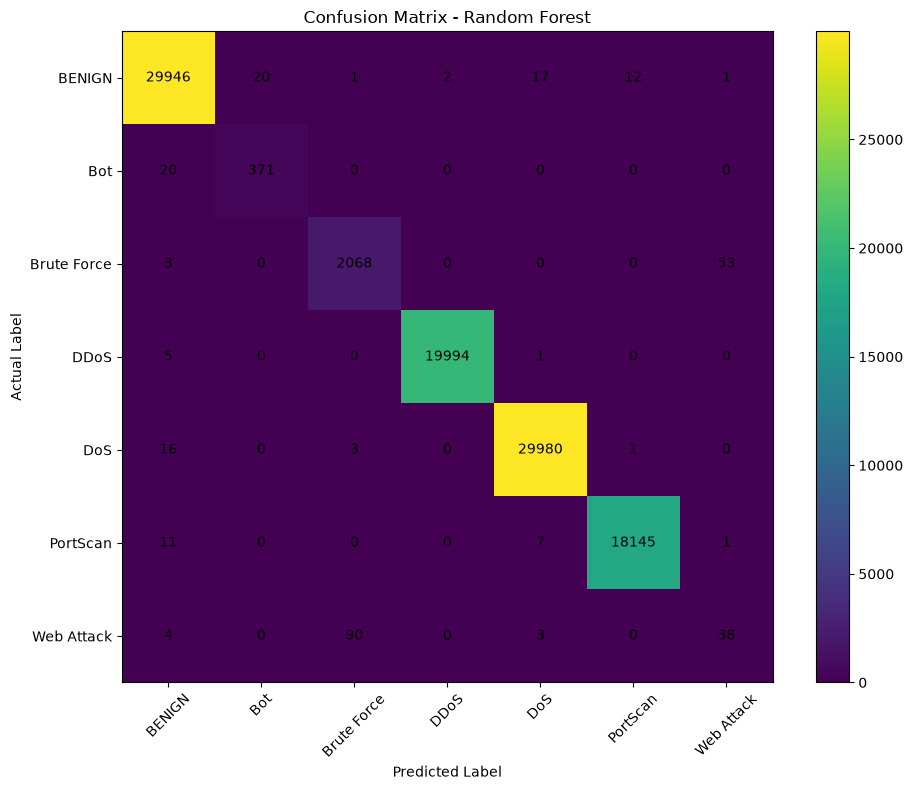

In [13]:
plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    ticks=np.arange(len(label_encoder.classes_)),
    labels=label_encoder.classes_,
    rotation=45
)

plt.yticks(
    ticks=np.arange(len(label_encoder.classes_)),
    labels=label_encoder.classes_
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

In [14]:
weighted_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

weighted_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [15]:
y_pred_weighted = weighted_model.predict(X_test)

print("Predictions generated:", len(y_pred_weighted))

Predictions generated: 100813


In [16]:
print(classification_report(
    y_test,
    y_pred_weighted,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     29999
         Bot       0.94      0.96      0.95       391
 Brute Force       0.95      0.97      0.96      2124
        DDoS       1.00      1.00      1.00     20000
         DoS       1.00      1.00      1.00     30000
    PortScan       1.00      1.00      1.00     18164
  Web Attack       0.35      0.25      0.29       135

    accuracy                           1.00    100813
   macro avg       0.89      0.88      0.89    100813
weighted avg       1.00      1.00      1.00    100813



In [17]:
cm_weighted = confusion_matrix(y_test, y_pred_weighted)

print(cm_weighted)

[[29932    26     2     3    24    12     0]
 [   14   377     0     0     0     0     0]
 [    1     0  2063     0     0     0    60]
 [    5     0     0 19994     1     0     0]
 [   15     0     3     0 29981     1     0]
 [    2     0     0     0     7 18153     2]
 [    3     0    96     0     2     0    34]]


In [18]:
import imblearn

print("imbalanced-learn version:", imblearn.__version__)

imbalanced-learn version: 0.14.2


In [19]:
import imblearn

print("imbalanced-learn version:", imblearn.__version__)

imbalanced-learn version: 0.14.2


In [20]:
import imblearn

print("imbalanced-learn version:", imblearn.__version__)

imbalanced-learn version: 0.14.2


In [21]:
import imblearn

print("imbalanced-learn version:", imblearn.__version__)

imbalanced-learn version: 0.14.2


In [22]:
import sys

print(sys.executable)
print(sys.version)

/Users/nishkamehta/Documents/ml-intrusion-detection/.venv/bin/python
3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 21.0.0 (clang-2100.0.123.102)]


In [23]:
import imblearn

print("imbalanced-learn version:", imblearn.__version__)

imbalanced-learn version: 0.14.2


In [24]:
print("Training class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nClass names:")
for encoded, name in enumerate(label_encoder.classes_):
    print(f"{encoded}: {name}")

Training class distribution:
0    119997
1      1562
2      8498
3     80000
4    120000
5     72655
6       538
Name: count, dtype: int64

Class names:
0: BENIGN
1: Bot
2: Brute Force
3: DDoS
4: DoS
5: PortScan
6: Web Attack


In [25]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy={
        1: 8500,   # Bot
        6: 8500    # Web Attack
    },
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Original training shape:", X_train.shape)
print("SMOTE training shape:", X_train_smote.shape)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index())

ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [26]:
nan_counts = X_train.isna().sum()

print("Total NaN values:", nan_counts.sum())

print("\nColumns containing NaN values:")
print(nan_counts[nan_counts > 0].sort_values(ascending=False))

Total NaN values: 382

Columns containing NaN values:
Flow Bytes/s      191
Flow Packets/s    191
dtype: int64


In [27]:
X_train_smote_input = X_train.copy()

X_train_smote_input = X_train_smote_input.fillna(
    X_train_smote_input.median()
)

print("Remaining NaN values:", X_train_smote_input.isna().sum().sum())

Remaining NaN values: 0


In [28]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_smote_input,
    y_train
)

print("Original training shape:", X_train.shape)
print("SMOTE training shape:", X_train_smote.shape)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index())

Original training shape: (403250, 78)
SMOTE training shape: (418150, 78)

Class distribution after SMOTE:
0    119997
1      8500
2      8498
3     80000
4    120000
5     72655
6      8500
Name: count, dtype: int64


In [29]:
smote_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

smote_model.fit(X_train_smote, y_train_smote)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [30]:
y_pred_smote = smote_model.predict(X_test)

print("Predictions generated:", len(y_pred_smote))

Predictions generated: 100813


In [31]:
print(classification_report(
    y_test,
    y_pred_smote,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     29999
         Bot       0.94      0.97      0.95       391
 Brute Force       0.98      0.93      0.96      2124
        DDoS       1.00      1.00      1.00     20000
         DoS       1.00      1.00      1.00     30000
    PortScan       1.00      1.00      1.00     18164
  Web Attack       0.39      0.67      0.49       135

    accuracy                           1.00    100813
   macro avg       0.90      0.94      0.91    100813
weighted avg       1.00      1.00      1.00    100813



In [32]:
cm_smote = confusion_matrix(y_test, y_pred_smote)

print(cm_smote)

[[29939    23     1     1    21    12     2]
 [   13   378     0     0     0     0     0]
 [    4     0  1984     0     0     0   136]
 [    6     0     0 19992     2     0     0]
 [   15     0     3     0 29982     0     0]
 [   11     0     0     0     7 18145     1]
 [    3     0    39     0     3     0    90]]


In [33]:
smote_accuracy = accuracy_score(y_test, y_pred_smote)

print(f"SMOTE Accuracy: {smote_accuracy:.4f}")
print(f"SMOTE Accuracy: {smote_accuracy * 100:.2f}%")

SMOTE Accuracy: 0.9970
SMOTE Accuracy: 99.70%


In [34]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Weighted Random Forest",
        "SMOTE Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_weighted),
        accuracy_score(y_test, y_pred_smote)
    ],
    "Macro Precision": [
        precision_score(y_test, y_pred, average="macro"),
        precision_score(y_test, y_pred_weighted, average="macro"),
        precision_score(y_test, y_pred_smote, average="macro")
    ],
    "Macro Recall": [
        recall_score(y_test, y_pred, average="macro"),
        recall_score(y_test, y_pred_weighted, average="macro"),
        recall_score(y_test, y_pred_smote, average="macro")
    ],
    "Macro F1": [
        f1_score(y_test, y_pred, average="macro"),
        f1_score(y_test, y_pred_weighted, average="macro"),
        f1_score(y_test, y_pred_smote, average="macro")
    ]
})

comparison

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Baseline Random Forest,0.997312,0.901465,0.885741,0.891920
1,Weighted Random Forest,0.997232,0.891378,0.883365,0.886095
2,SMOTE Random Forest,0.996994,0.901557,0.937637,0.914453
